## Comparação no título

Os três modelos classificam a manchete (`titulo`), com o mesmo recorte e a mesma representação. O TF-IDF e a escala dos sinais numéricos são ajustados só no treino.

Além das palavras, cada manchete entra com seis sinais: aspas, dois-pontos, inicial minúscula, número, `titulo_prob_negativo` e `titulo_prob_positivo`.

O teste deixa sites inteiros de fora: `projetocomprova.com.br`, `e-farsas.com` e `g1.globo.com`. Entram só o título, esses sinais e o rótulo.

Títulos vazios e o título que aparece com os dois rótulos saem antes da divisão.


In [1]:
%matplotlib inline

import sys
from pathlib import Path

for candidato in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidato / "classificacao").is_dir():
        if str(candidato) not in sys.path:
            sys.path.insert(0, str(candidato))
        break

from classificacao import (
    carregar_manchetes,
    desenhar_matrizes,
    representar,
    resumo,
    separar_por_sites,
    sinais_da_manchete,
    tabela,
    treinar_e_prever,
    validar_por_dominio,
)

base = carregar_manchetes()
treino, teste = separar_por_sites(base)
y_treino = treino["rotulo"]
y_teste = teste["rotulo"]
treino.shape, teste.shape, y_treino.value_counts().to_dict(), y_teste.value_counts().to_dict()

((7135, 20), (1400, 20), {1: 3632, 0: 3503}, {1: 748, 0: 652})

In [2]:
X_treino, X_teste = representar(
    treino["titulo"],
    sinais_da_manchete(treino),
    teste["titulo"],
    sinais_da_manchete(teste),
)
X_treino.shape, X_teste.shape

/home/Jow/Documentos/projetos/residencia/svm/.venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/Jow/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


((7135, 5006), (1400, 5006))

In [3]:
previsoes = treinar_e_prever(X_treino, y_treino, X_teste)
tabela(previsoes, y_teste).round(3)

,acurácia,precisão,recall,f1
modelo,,,,
Regressão logística,0.819,0.820,0.821,0.819
SVM,0.793,0.792,0.794,0.792
Random Forest,0.794,0.793,0.792,0.792


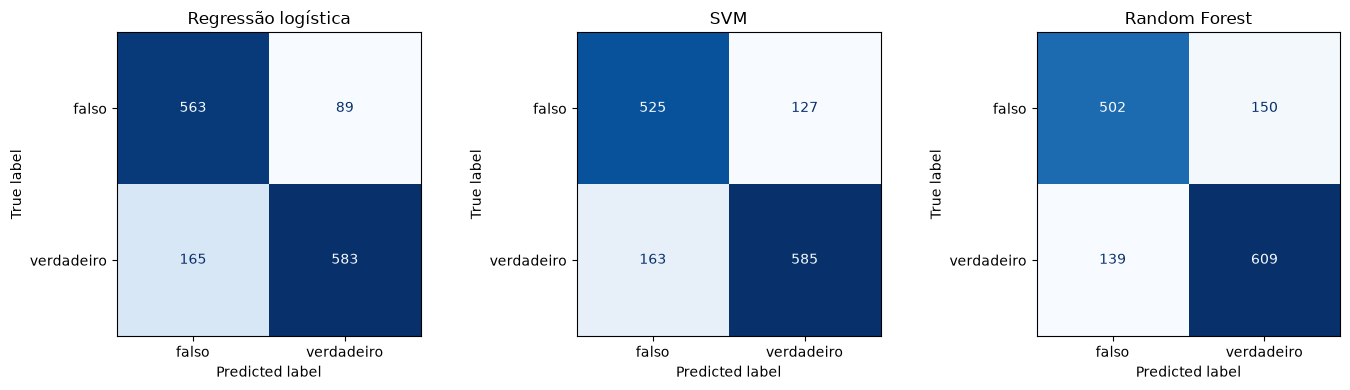

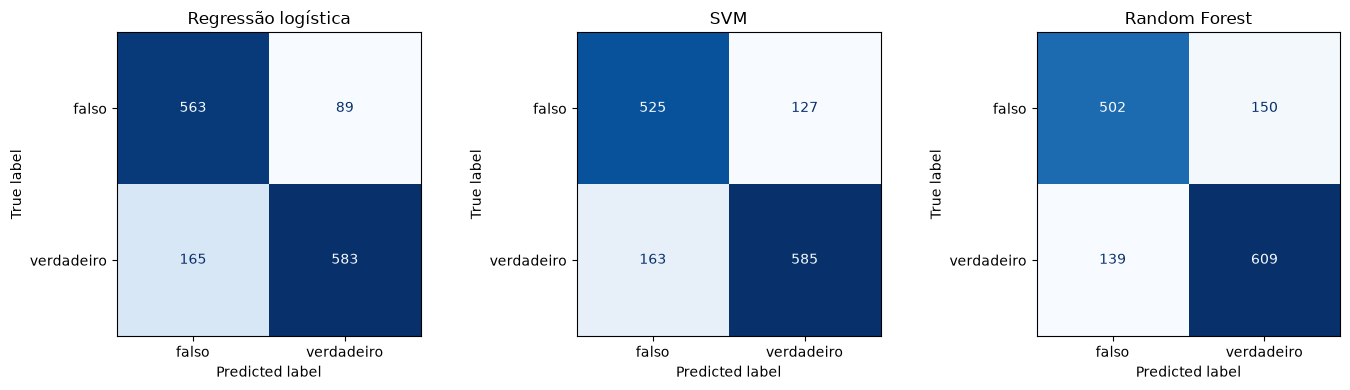

In [4]:
desenhar_matrizes(previsoes, y_teste)

## Leitura da comparação

A precisão, o recall e o F1 são a média das duas classes. O teste tem 652 manchetes falsas e 748 verdadeiras.

Com os seis sinais da manchete, a regressão logística fica na frente neste corte: acurácia e F1 de 0,819. A Random Forest chega a 0,794 e a SVM a 0,793. Antes, só com as palavras, a logística estava em 0,783 e a floresta em 0,746.

Aspas, dois-pontos, inicial minúscula, número e o sentimento ajudaram os três. Neste grupo de sites, a logística aproveitou melhor a soma desses sinais.

## Validação cruzada por site

O `StratifiedGroupKFold` reparte os domínios em 4 dobras. Cada site entra em um único teste, e cada dobra tem manchetes falsas e verdadeiras. O TF-IDF é ajustado de novo dentro de cada treino, com os mesmos parâmetros. Os três modelos veem as mesmas dobras.

In [5]:
por_dobra = validar_por_dominio(base)
resumo(por_dobra)

Dobra 1: teste 2707 | boatos.org, economia.uol.com.br, educacao.uol.com.br, entretenimento.uol.com.br, tvefamosos.uol.com.br, uol.com.br


Dobra 2: teste 2571 | projetocomprova.com.br, sem url


Dobra 3: teste 1584 | e-farsas.com, noticias.uol.com.br


Dobra 4: teste 1673 | checamos.afp.com, g1.globo.com


,acurácia,precisão,recall,f1
modelo,,,,
Random Forest,0.607,0.652,0.739,0.571
Regressão logística,0.641,0.664,0.760,0.600
SVM,0.708,0.686,0.790,0.653


In [6]:
por_dobra.round(3)

,modelo,dobra,acurácia,precisão,recall,f1
0,Regressão logística,1,0.303,0.532,0.626,0.273
1,SVM,1,0.428,0.538,0.685,0.358
2,Random Forest,1,0.246,0.529,0.596,0.230
3,Regressão logística,2,0.736,0.683,0.817,0.680
4,SVM,2,0.810,0.722,0.849,0.745
5,Random Forest,2,0.713,0.675,0.809,0.661
6,Regressão logística,3,0.756,0.673,0.825,0.679
7,SVM,3,0.804,0.693,0.831,0.717
8,Random Forest,3,0.730,0.657,0.802,0.653
9,Regressão logística,4,0.769,0.769,0.772,0.769


## Leitura da validação cruzada

Na média das 4 dobras, a SVM continua na frente: acurácia 0,708 e F1 0,653. A regressão logística fica em 0,641 e 0,600. A Random Forest fica em 0,607 e 0,571.

O ganho aparece nas dobras 2, 3 e 4. A dobra 1, quase toda `boatos.org`, segue difícil: a SVM tem F1 0,358 e a logística 0,273. O formato da manchete não basta para reconhecer esse site quando ele não entrou no treino.

A SVM é o modelo mais estável quando os sites mudam. A logística ganha no corte único e perde na média das quatro provas.